# Data Exploration - Superstore Sales Dataset
## Initial Data Analysis and Understanding

In [1]:
%pip install loguru
%pip install PyYAML

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src to path
sys.path.append(str(Path.cwd().parent))

from src.utils.logger import logger
from src.data.load_data import DataLoader
from src.data.clean_data import DataCleaner

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
# %matplotlib inline

2026-03-13 19:15:01 | WARNING | src.utils.config:37 | Config file config.yaml not found, using defaults
2026-03-13 19:15:01 | WARNING | src.utils.config:50 | .env file not found, using system environment variables
2026-03-13 19:15:01 | INFO | src.utils.config:24 | Configuration loaded from config.yaml


In [3]:
# Load data
loader = DataLoader()
df = loader.load_raw_data()
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

2026-03-13 19:15:01 | INFO | src.data.load_data:31 | DataLoader initialized with raw path: C:\Users\Vasu\Anti Gravity\practice-projects\sales-analytics-dashboard\data\raw\superstore_sales.csv
2026-03-13 19:15:01 | INFO | src.data.load_data:54 | Loading raw data from C:\Users\Vasu\Anti Gravity\practice-projects\sales-analytics-dashboard\data\raw\superstore_sales.csv
2026-03-13 19:15:01 | INFO | src.data.load_data:65 | Loaded 9994 rows from C:\Users\Vasu\Anti Gravity\practice-projects\sales-analytics-dashboard\data\raw\superstore_sales.csv
2026-03-13 19:15:01 | INFO | src.data.load_data:87 | Validating raw data structure
2026-03-13 19:15:01 | INFO | src.data.load_data:104 | Data types: {'Row ID': dtype('int64'), 'Order ID': dtype('O'), 'Order Date': dtype('O'), 'Ship Date': dtype('O'), 'Ship Mode': dtype('O'), 'Customer ID': dtype('O'), 'Customer Name': dtype('O'), 'Segment': dtype('O'), 'Country': dtype('O'), 'City': dtype('O'), 'State': dtype('O'), 'Postal Code': dtype('int64'), 'Regio

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Data information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64

In [5]:
# Basic statistics
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Percentage


In [7]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [8]:
# Unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique values")

Order ID: 5009 unique values
Order Date: 1237 unique values
Ship Date: 1334 unique values
Ship Mode: 4 unique values
Customer ID: 793 unique values
Customer Name: 793 unique values
Segment: 3 unique values
Country: 1 unique values
City: 531 unique values
State: 49 unique values
Region: 4 unique values
Product ID: 1862 unique values
Category: 3 unique values
Sub-Category: 17 unique values
Product Name: 1850 unique values


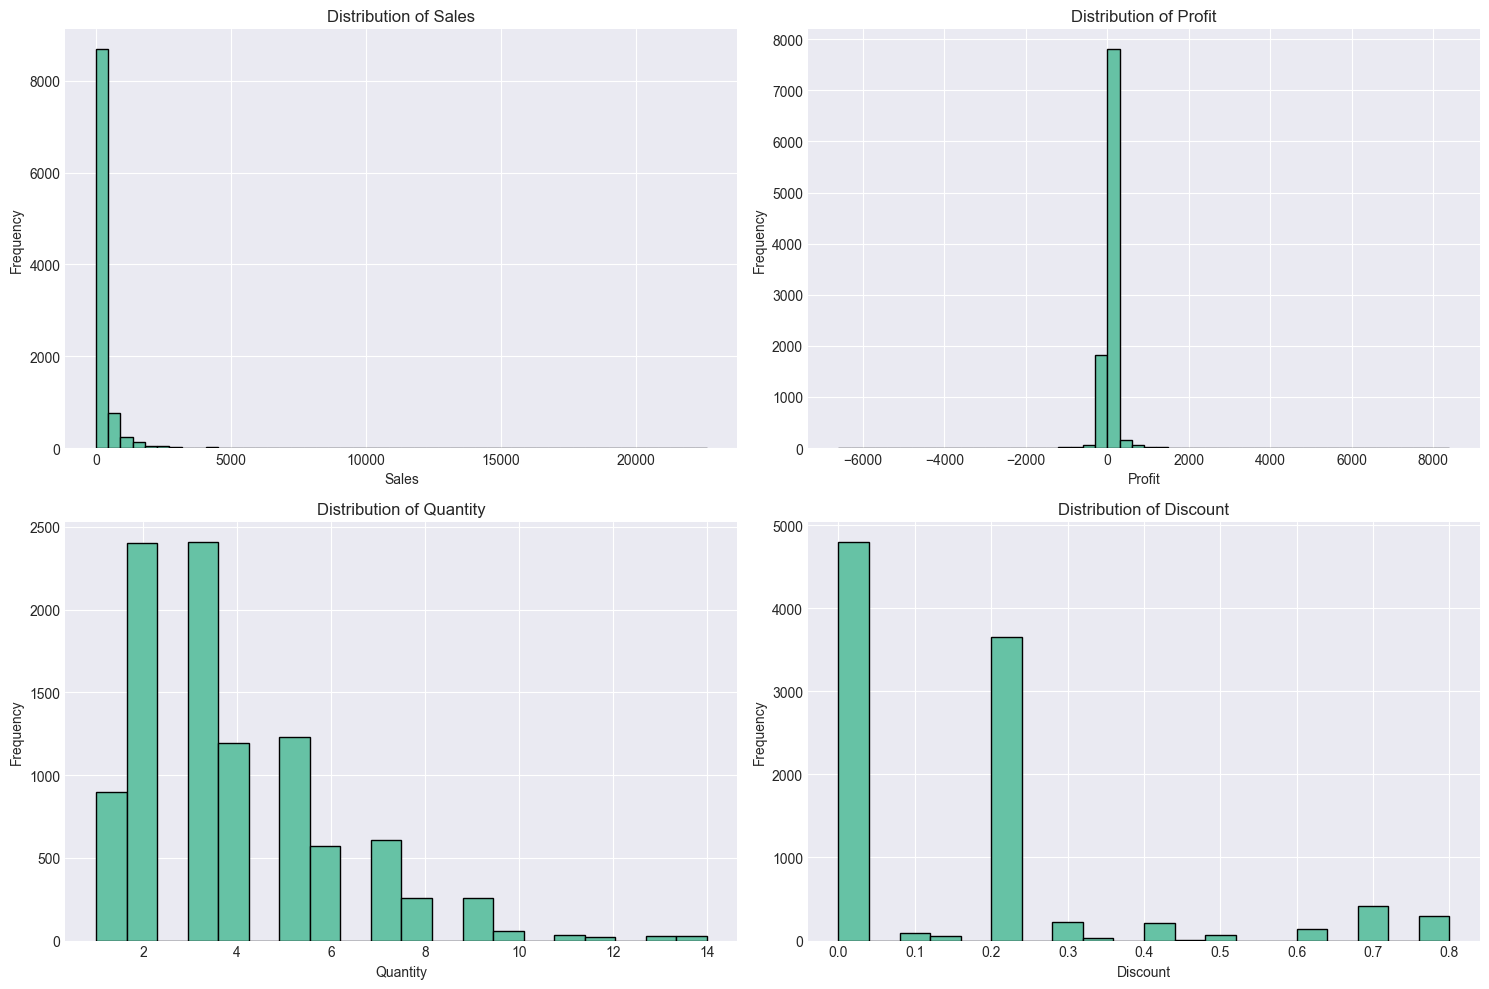

In [9]:
# Distribution of key metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sales distribution
axes[0, 0].hist(df['Sales'], bins=50, edgecolor='black')
axes[0, 0].set_title('Distribution of Sales')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')

# Profit distribution
axes[0, 1].hist(df['Profit'], bins=50, edgecolor='black')
axes[0, 1].set_title('Distribution of Profit')
axes[0, 1].set_xlabel('Profit')
axes[0, 1].set_ylabel('Frequency')

# Quantity distribution
axes[1, 0].hist(df['Quantity'], bins=20, edgecolor='black')
axes[1, 0].set_title('Distribution of Quantity')
axes[1, 0].set_xlabel('Quantity')
axes[1, 0].set_ylabel('Frequency')

# Discount distribution
axes[1, 1].hist(df['Discount'], bins=20, edgecolor='black')
axes[1, 1].set_title('Distribution of Discount')
axes[1, 1].set_xlabel('Discount')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

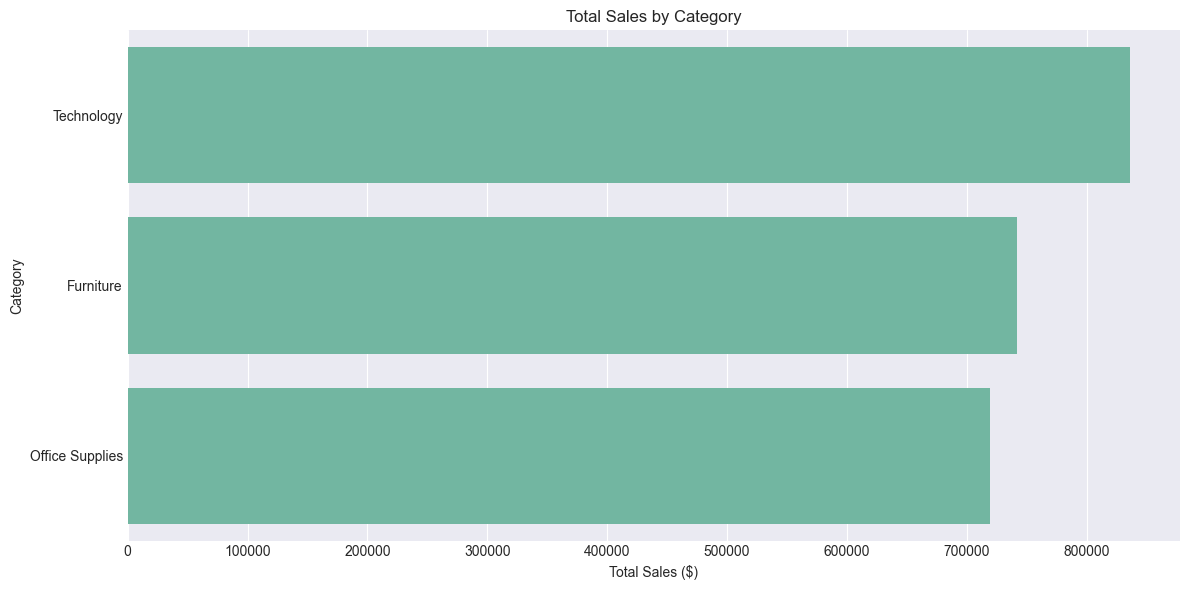

In [10]:
# Sales by category
plt.figure(figsize=(12, 6))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.values, y=category_sales.index)
plt.title('Total Sales by Category')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

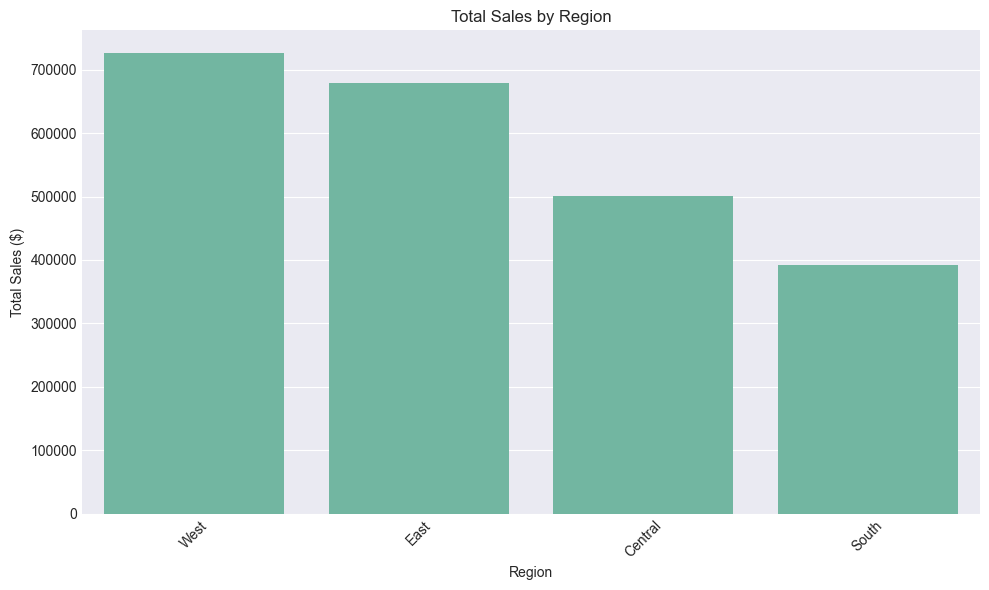

In [11]:
# Sales by region
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

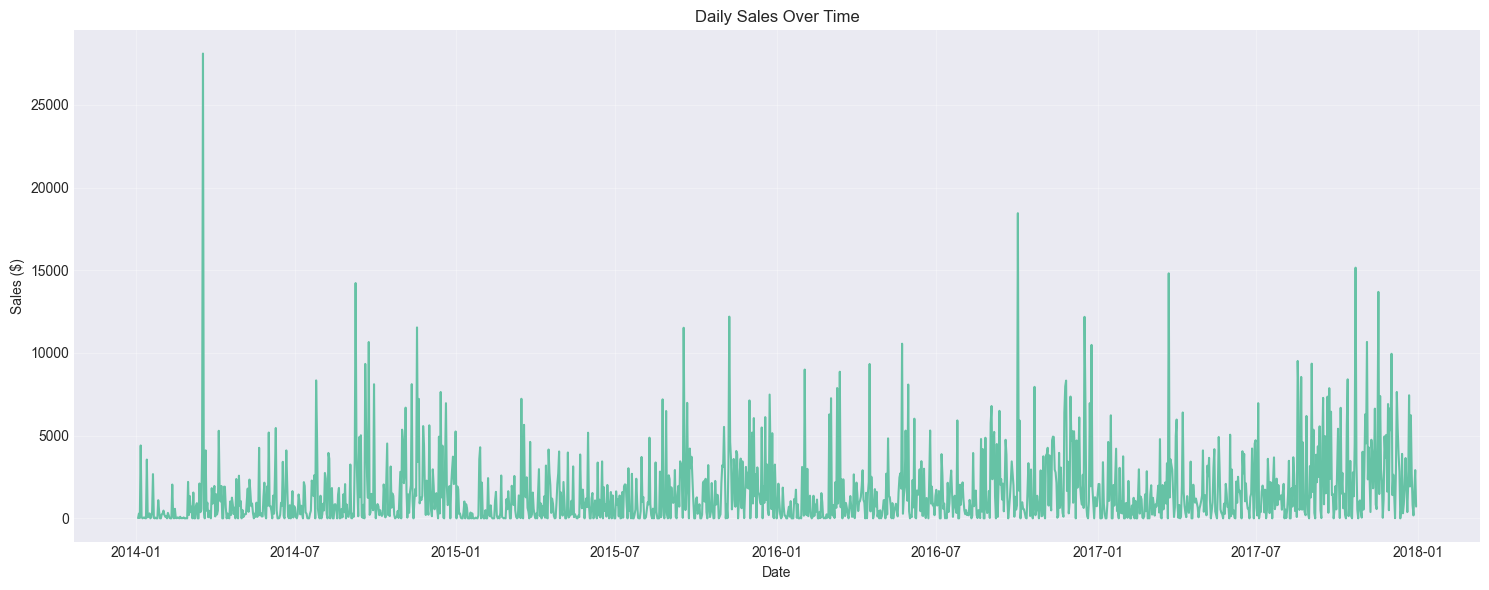

In [12]:
# Time series analysis
df['Order Date'] = pd.to_datetime(df['Order Date'])
daily_sales = df.set_index('Order Date').resample('D')['Sales'].sum()

plt.figure(figsize=(15, 6))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

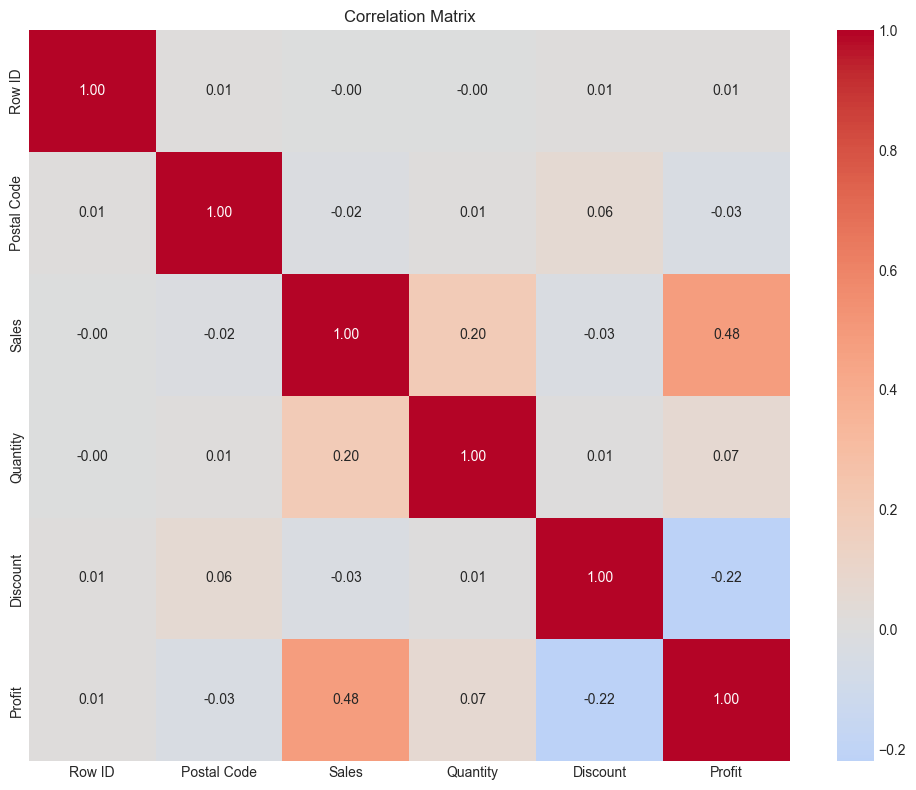

In [13]:
# Correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()